In [1]:
import pandas as pd

In [2]:
iris= pd.read_csv("data/iris.csv")

In [3]:
iris.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


In [4]:
# this dataset is very balanced across all three classes
iris["species"].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [5]:
# check the null values
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
# get data insights and visualize distributions
from ydata_profiling import ProfileReport

profile = ProfileReport(iris)

In [7]:
# split target and independent variables
X= iris.drop("species", axis=1)
y= iris["species"]

In [8]:
X.head(2)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [9]:
y[:2]

0    setosa
1    setosa
Name: species, dtype: object

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# split the data into train and test
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.25, random_state=42)

In [12]:
X_train.shape,   y_train.shape

((112, 4), (112,))

In [13]:
X_test.shape, y_test.shape

((38, 4), (38,))

In [14]:
# lets encode the labels. Here i am using label encoding.
from sklearn.preprocessing import LabelEncoder

In [15]:
# intializing the label encoder
encoder= LabelEncoder()

In [16]:
# fit and transform on train data
y_train_encoded= encoder.fit_transform(y_train)

In [17]:
# transform on test data to avoid data leakage
y_test_encoded= encoder.transform(y_test)

In [18]:
# to know which class assigned to which label
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

In [19]:
label_mapping

{'setosa': 0, 'versicolor': 1, 'virginica': 2}

# Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
#initialize the decision tree classifier
# by default this will take criterion is Gini. 
# you can use criterion: {“gini”, “entropy”, “log_loss”}

classifier= DecisionTreeClassifier()

In [22]:
# fit the model to train data
classifier.fit(X_train, y_train_encoded)

DecisionTreeClassifier()

In [23]:
# we can see the tree also how our decision Tree built a tree
from sklearn import tree
import matplotlib.pyplot as plt

[Text(0.3076923076923077, 0.9285714285714286, 'petal_length <= 2.45\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]\nclass = versicolor'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]\nclass = setosa'),
 Text(0.38461538461538464, 0.7857142857142857, 'petal_length <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0, 39, 38]\nclass = versicolor'),
 Text(0.15384615384615385, 0.6428571428571429, 'petal_width <= 1.65\ngini = 0.056\nsamples = 35\nvalue = [0, 34, 1]\nclass = versicolor'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 34\nvalue = [0, 34, 0]\nclass = versicolor'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.6153846153846154, 0.6428571428571429, 'petal_width <= 1.75\ngini = 0.21\nsamples = 42\nvalue = [0, 5, 37]\nclass = virginica'),
 Text(0.38461538461538464, 0.5, 'petal_length <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]\nclass = versicolor'),
 Text(0.3076

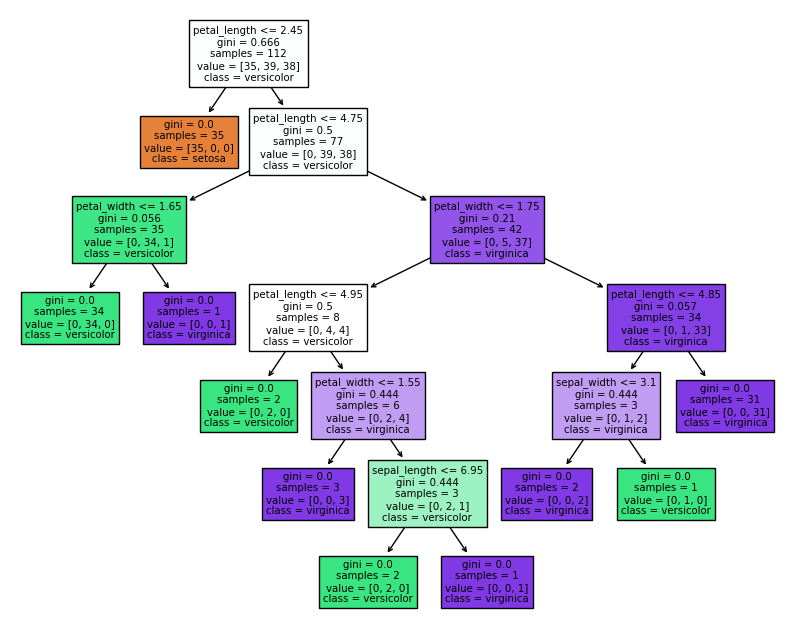

In [28]:
plt.figure(figsize=(10,8))
tree.plot_tree(classifier, filled=True, feature_names=X.columns, class_names= y.unique())

Note: if you see the above Decision Tree, its built until complete depth and we have 2 leaf nodes at the end. It must be overfitted.


In [29]:
# predictions
y_pred= classifier.predict(X_test)

In [37]:
# lets get the metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [31]:
accuracy = accuracy_score(y_test_encoded, y_pred)
conf_matrix= confusion_matrix(y_test_encoded, y_pred)
class_report= classification_report(y_test_encoded, y_pred)

In [32]:
accuracy

1.0

In [33]:
conf_matrix

array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)

In [34]:
print(class_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



# ROC-AUC curve

In [38]:
from sklearn.metrics import roc_curve, auc

In [48]:
# you need probability values inorder to build ROC
y_pred_proba= classifier.predict_proba(X_test)

In [49]:
# lets get the number of class in the target, we need this inorder to plot roc curve
n_classes= len(y.unique())

In [50]:
n_classes

3

In [51]:
# lets calculate fpr, tpr( note thresholds is not required for ROC and AUC so i left with empty "_") i used here "auc" you can use directly "roc_acu_score" metric also
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded == i, y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

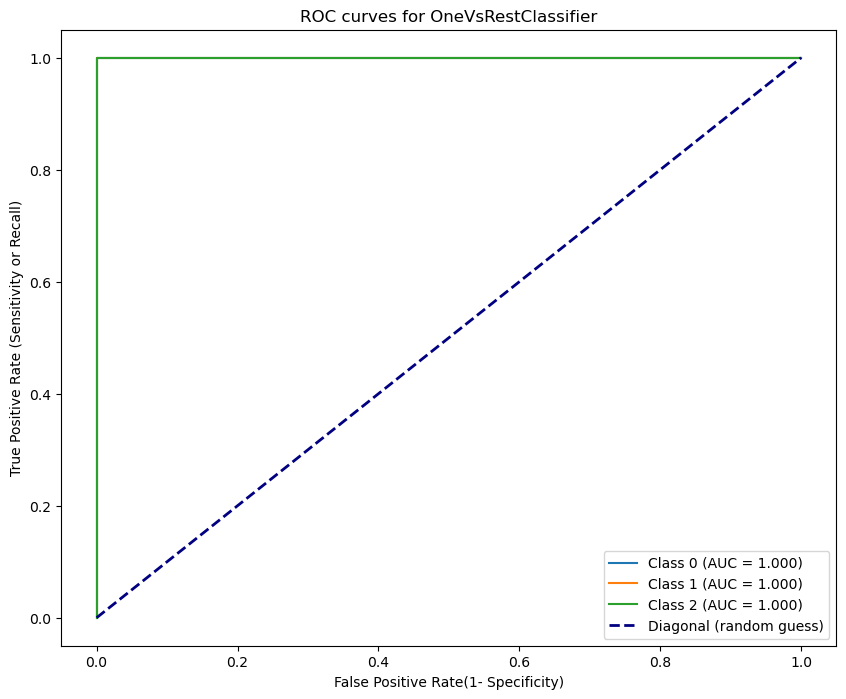

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Diagonal (random guess)')
plt.xlabel('False Positive Rate(1- Specificity)')
plt.ylabel('True Positive Rate (Sensitivity or Recall)')
plt.title('ROC curves for OneVsRestClassifier')
plt.legend()
plt.show()

# Precision - Recall Curve

In [53]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [54]:
precision = dict()
recall = dict()
avg_precision = dict() # this is nothing but Auc under precision-recall curve

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_encoded==i, y_pred_proba[:,i])
    avg_precision[i] = average_precision_score(y_test_encoded==i, y_pred_proba[:,i])

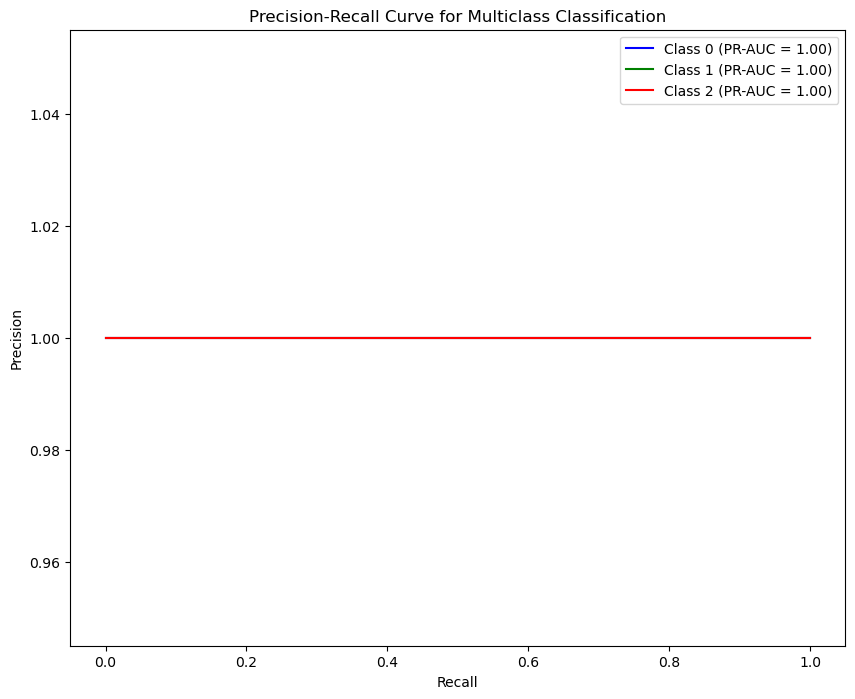

In [56]:
plt.figure(figsize=(10, 8))
colors= ["b", "g", "r"]
for i in range(n_classes):
    # generally we go with plt.step than plt.plot in precision-recall plot as they change very frquent 
    plt.step(recall[i], precision[i], where="post", color= colors[i], label=f"Class {i} (PR-AUC = {avg_precision[i]:.2f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Multiclass Classification')
plt.legend()
plt.show()

# Post-Pruning (Regularization in DT)

Note:  you can pass this max_depth parameter before building the DecisionTree also and we call it as Pre-Pruning.

In [57]:
# decide the depth by watching the above figure, we can calcualte this using hyper-parameter tuning as well
classifier_pruning= DecisionTreeClassifier(max_depth=4)

In [58]:
classifier_pruning.fit(X_train, y_train_encoded)

DecisionTreeClassifier(max_depth=4)

[Text(0.3181818181818182, 0.9, 'X[2] <= 2.45\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]'),
 Text(0.22727272727272727, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.4090909090909091, 0.7, 'X[2] <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0, 39, 38]'),
 Text(0.18181818181818182, 0.5, 'X[3] <= 1.65\ngini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.09090909090909091, 0.3, 'gini = 0.0\nsamples = 34\nvalue = [0, 34, 0]'),
 Text(0.2727272727272727, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6363636363636364, 0.5, 'X[3] <= 1.75\ngini = 0.21\nsamples = 42\nvalue = [0, 5, 37]'),
 Text(0.45454545454545453, 0.3, 'X[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.36363636363636365, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.5454545454545454, 0.1, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.8181818181818182, 0.3, 'X[2] <= 4.85\ngini = 0.057\nsamples = 34\nvalue = [0, 1, 33]'),
 Text(0.7272727272727273, 

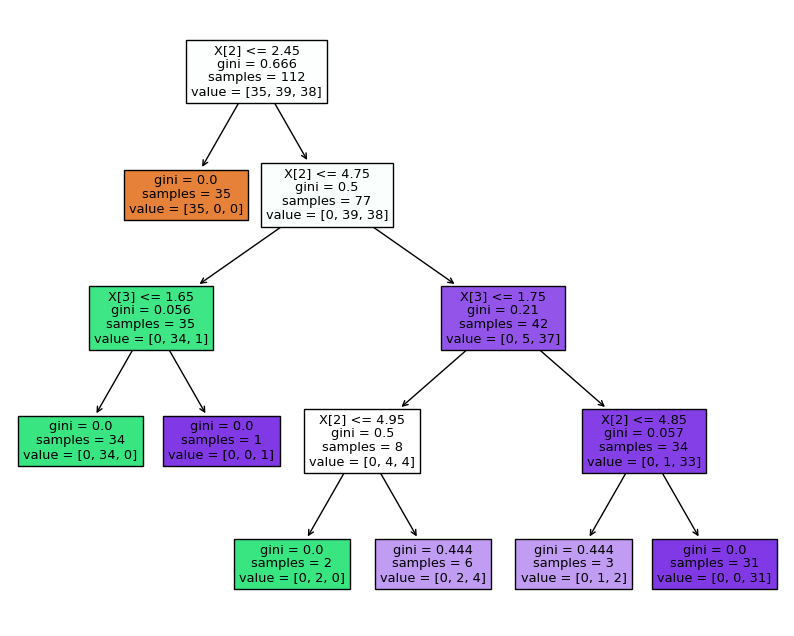

In [59]:
plt.figure(figsize=(10,8))
tree.plot_tree(classifier_pruning, filled=True)

In [60]:
# predictions
y_pred_pruning= classifier_pruning.predict(X_test)

In [61]:
# metrics
accuracy_pruning= accuracy_score(y_test_encoded, y_pred_pruning)
conf_matrix_pruning= confusion_matrix(y_test_encoded, y_pred_pruning)
class_report_pruning= classification_report(y_test_encoded, y_pred_pruning)

In [62]:
accuracy_pruning

1.0

In [63]:
conf_matrix_pruning

array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)

In [64]:
print(class_report_pruning)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



Note: you can build same Decision Tree by applying citerion= "entropy". I have used here default Gini in sklearn